# 🏆 Comparaison de Modèles — Prédiction RUL CMAPSS FD001

**8 modèles comparés :**

| Catégorie | Modèles |
|-----------|----------|
| ML Classique | Random Forest, XGBoost, SVR |
| Deep Learning | LSTM, Bi-LSTM, CNN-LSTM |
| Hybrides | CNN-LSTM-Attention, Transformer |

**Métriques** : RMSE · MAE · Score NASA · Temps d'entraînement

## 📦 1. Installation & Imports

In [ ]:
!pip install xgboost lightgbm -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# ML Classique
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import xgboost as xgb

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Bidirectional, Dense, Dropout, BatchNormalization,
    Conv1D, MaxPooling1D, Flatten, GlobalAveragePooling1D,
    MultiHeadAttention, LayerNormalization, Input, Add
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print('✅ Librairies importées')
print(f'TensorFlow : {tf.__version__}')
print(f'GPU dispo  : {len(tf.config.list_physical_devices("GPU")) > 0}')

✅ Librairies importées
TensorFlow : 2.20.0
GPU dispo  : True


## 📁 2. Upload du fichier train_FD001.txt

In [ ]:
from google.colab import files

print('📂 Uploadez votre fichier train_FD001.txt')
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
print(f'\n✅ Fichier uploadé : {file_name}')

📂 Uploadez votre fichier train_FD001.txt


Saving train_FD001.txt to train_FD001.txt

✅ Fichier uploadé : train_FD001.txt


## 🔧 3. Preprocessing commun à tous les modèles

In [ ]:
# ── Constantes ──────────────────────────────────────────────────────────────
RUL_MAX     = 125   # Clip RUL (recommandation NASA FD001)
WINDOW_SIZE = 30    # Fenêtre glissante pour les modèles séquentiels
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ── Colonnes ────────────────────────────────────────────────────────────────
columns = [
    'unit_id', 'cycle',
    'op_setting_1', 'op_setting_2', 'op_setting_3',
    *[f'sensor_{i}' for i in range(1, 22)]
]

# Capteurs à variance nulle pour FD001
DROP_SENSORS  = ['sensor_1','sensor_5','sensor_6','sensor_10',
                 'sensor_16','sensor_18','sensor_19']
sensor_cols   = [f'sensor_{i}' for i in range(1, 22) if f'sensor_{i}' not in DROP_SENSORS]
op_cols       = ['op_setting_1', 'op_setting_2', 'op_setting_3']
feature_cols  = op_cols + sensor_cols

# ── Chargement ──────────────────────────────────────────────────────────────
df = pd.read_csv(file_name, sep=' ', header=None, names=columns, index_col=False)
df.dropna(axis=1, how='all', inplace=True)
df.dropna(inplace=True)

# ── Calcul RUL ──────────────────────────────────────────────────────────────
max_cycles = df.groupby('unit_id')['cycle'].max().reset_index()
max_cycles.columns = ['unit_id', 'max_cycle']
df = df.merge(max_cycles, on='unit_id')
df['RUL']         = df['max_cycle'] - df['cycle']
df['RUL_clipped'] = df['RUL'].clip(upper=RUL_MAX)

# ── Normalisation ────────────────────────────────────────────────────────────
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
df[feature_cols]  = scaler_X.fit_transform(df[feature_cols])
df['RUL_scaled']  = scaler_y.fit_transform(df[['RUL_clipped']])

print(f'✅ Preprocessing terminé')
print(f'   Moteurs   : {df["unit_id"].nunique()}')
print(f'   Lignes    : {len(df)}')
print(f'   Features  : {len(feature_cols)} ({feature_cols})')

✅ Preprocessing terminé
   Moteurs   : 100
   Lignes    : 20631
   Features  : 17 (['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21'])


## 🏗️ 4. Création des datasets
**Flat** (ML classique) · **Séquences** (Deep Learning)

In [ ]:
# ── Dataset FLAT pour ML Classique ──────────────────────────────────────────
X_flat = df[feature_cols].values
y_flat = df['RUL_scaled'].values

X_flat_train, X_flat_val, y_flat_train, y_flat_val = train_test_split(
    X_flat, y_flat, test_size=0.2, random_state=RANDOM_SEED
)

# ── Dataset SÉQUENTIEL pour Deep Learning ───────────────────────────────────
def create_sequences(data, feature_cols, target_col, window_size):
    X, y = [], []
    for unit_id in data['unit_id'].unique():
        unit = data[data['unit_id'] == unit_id].sort_values('cycle')
        feats   = unit[feature_cols].values
        targets = unit[target_col].values
        if len(feats) < window_size:
            pad = window_size - len(feats)
            feats   = np.vstack([np.zeros((pad, len(feature_cols))), feats])
            targets = np.hstack([np.zeros(pad), targets])
        for i in range(len(feats) - window_size + 1):
            X.append(feats[i:i+window_size])
            y.append(targets[i+window_size-1])
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(df, feature_cols, 'RUL_scaled', WINDOW_SIZE)
X_seq_train, X_seq_val, y_seq_train, y_seq_val = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=RANDOM_SEED
)

n_features = len(feature_cols)
print(f'✅ Datasets prêts')
print(f'   Flat  — Train : {X_flat_train.shape} | Val : {X_flat_val.shape}')
print(f'   Seq   — Train : {X_seq_train.shape}  | Val : {X_seq_val.shape}')

✅ Datasets prêts
   Flat  — Train : (16504, 17) | Val : (4127, 17)
   Seq   — Train : (14184, 30, 17)  | Val : (3547, 30, 17)


## 🛠️ 5. Fonctions utilitaires

In [ ]:
def nasa_score(y_true, y_pred):
    """Score NASA : pénalise davantage les sous-estimations"""
    diff = y_pred - y_true
    return float(np.sum(np.where(diff < 0,
                                 np.exp(-diff / 13) - 1,
                                 np.exp( diff / 10) - 1)))

def evaluate(y_true_scaled, y_pred_scaled, model_name, train_time):
    """Dénormalise et calcule toutes les métriques"""
    y_true = scaler_y.inverse_transform(y_true_scaled.reshape(-1,1)).flatten()
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).flatten()
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    mae    = mean_absolute_error(y_true, y_pred)
    nasa   = nasa_score(y_true, y_pred)
    print(f'  [{model_name}] RMSE={rmse:.2f} | MAE={mae:.2f} | NASA={nasa:.0f} | t={train_time:.1f}s')
    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'NASA_Score': nasa,
            'Train_Time_s': train_time, 'y_true': y_true, 'y_pred': y_pred}

DL_CALLBACKS = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=0)
]

results = []   # Liste qui contiendra les résultats de tous les modèles
print('✅ Fonctions utilitaires prêtes — démarrage des modèles...')

✅ Fonctions utilitaires prêtes — démarrage des modèles...


---
# 🤖 MODÈLES ML CLASSIQUES

## 🌲 6. Random Forest

In [ ]:
print('🌲 Entraînement Random Forest...')
t0 = time.time()

rf = RandomForestRegressor(n_estimators=200, max_depth=15,
                            min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_SEED)
rf.fit(X_flat_train, y_flat_train)

t_rf = time.time() - t0
y_pred_rf = rf.predict(X_flat_val)
results.append(evaluate(y_flat_val, y_pred_rf, 'Random Forest', t_rf))

🌲 Entraînement Random Forest...
  [Random Forest] RMSE=18.62 | MAE=13.37 | NASA=63950 | t=25.8s


## ⚡ 7. XGBoost

In [ ]:
print('⚡ Entraînement XGBoost...')
t0 = time.time()

xgb_model = xgb.XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    early_stopping_rounds=20, eval_metric='rmse',
    random_state=RANDOM_SEED, verbosity=0
)
xgb_model.fit(X_flat_train, y_flat_train,
              eval_set=[(X_flat_val, y_flat_val)], verbose=False)

t_xgb = time.time() - t0
y_pred_xgb = xgb_model.predict(X_flat_val)
results.append(evaluate(y_flat_val, y_pred_xgb, 'XGBoost', t_xgb))

⚡ Entraînement XGBoost...
  [XGBoost] RMSE=18.55 | MAE=13.37 | NASA=64055 | t=0.8s


## 🔷 8. SVR (Support Vector Regression)

In [ ]:
print('🔷 Entraînement SVR (sur un sous-ensemble pour vitesse)...')
t0 = time.time()

# SVR est lent sur gros datasets → on utilise un sous-ensemble
MAX_SVR = 10000
idx = np.random.choice(len(X_flat_train), min(MAX_SVR, len(X_flat_train)), replace=False)

svr = SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.05)
svr.fit(X_flat_train[idx], y_flat_train[idx])

t_svr = time.time() - t0
y_pred_svr = svr.predict(X_flat_val)
results.append(evaluate(y_flat_val, y_pred_svr, 'SVR', t_svr))

🔷 Entraînement SVR (sur un sous-ensemble pour vitesse)...
  [SVR] RMSE=19.49 | MAE=13.58 | NASA=111450 | t=14.5s


---
# 🧠 MODÈLES DEEP LEARNING

## 🔁 9. LSTM

In [ ]:
print('🔁 Entraînement LSTM...')

def build_lstm(input_shape):
    m = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        BatchNormalization(), Dropout(0.3),
        LSTM(64, return_sequences=True),
        BatchNormalization(), Dropout(0.3),
        LSTM(32),
        BatchNormalization(), Dropout(0.2),
        Dense(32, activation='relu'), Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

t0 = time.time()
lstm_model = build_lstm((WINDOW_SIZE, n_features))
lstm_model.fit(X_seq_train, y_seq_train,
               validation_data=(X_seq_val, y_seq_val),
               epochs=80, batch_size=256,
               callbacks=DL_CALLBACKS, verbose=0)

t_lstm = time.time() - t0
y_pred_lstm = lstm_model.predict(X_seq_val, verbose=0).flatten()
results.append(evaluate(y_seq_val, y_pred_lstm, 'LSTM', t_lstm))

🔁 Entraînement LSTM...
  [LSTM] RMSE=4.52 | MAE=3.13 | NASA=1393 | t=91.7s


## ↔️ 10. Bi-LSTM

In [ ]:
print('↔️ Entraînement Bi-LSTM...')

def build_bilstm(input_shape):
    m = Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=input_shape),
        BatchNormalization(), Dropout(0.3),
        Bidirectional(LSTM(32, return_sequences=True)),
        BatchNormalization(), Dropout(0.3),
        Bidirectional(LSTM(16)),
        BatchNormalization(), Dropout(0.2),
        Dense(32, activation='relu'), Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

t0 = time.time()
bilstm_model = build_bilstm((WINDOW_SIZE, n_features))
bilstm_model.fit(X_seq_train, y_seq_train,
                 validation_data=(X_seq_val, y_seq_val),
                 epochs=80, batch_size=256,
                 callbacks=DL_CALLBACKS, verbose=0)

t_bilstm = time.time() - t0
y_pred_bilstm = bilstm_model.predict(X_seq_val, verbose=0).flatten()
results.append(evaluate(y_seq_val, y_pred_bilstm, 'Bi-LSTM', t_bilstm))

↔️ Entraînement Bi-LSTM...
  [Bi-LSTM] RMSE=35.52 | MAE=31.52 | NASA=93961 | t=22.7s


## 🔶 11. CNN-LSTM

In [ ]:
print('🔶 Entraînement CNN-LSTM...')

def build_cnn_lstm(input_shape):
    m = Sequential([
        # Bloc CNN : extraction locale de patterns
        Conv1D(64, kernel_size=3, activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        # Bloc LSTM : dépendances temporelles
        LSTM(64, return_sequences=True),
        BatchNormalization(), Dropout(0.3),
        LSTM(32),
        BatchNormalization(), Dropout(0.2),
        Dense(32, activation='relu'), Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

t0 = time.time()
cnn_lstm_model = build_cnn_lstm((WINDOW_SIZE, n_features))
cnn_lstm_model.fit(X_seq_train, y_seq_train,
                   validation_data=(X_seq_val, y_seq_val),
                   epochs=80, batch_size=256,
                   callbacks=DL_CALLBACKS, verbose=0)

t_cnn_lstm = time.time() - t0
y_pred_cnn_lstm = cnn_lstm_model.predict(X_seq_val, verbose=0).flatten()
results.append(evaluate(y_seq_val, y_pred_cnn_lstm, 'CNN-LSTM', t_cnn_lstm))

🔶 Entraînement CNN-LSTM...
  [CNN-LSTM] RMSE=40.89 | MAE=36.59 | NASA=273079 | t=16.7s


---
# 🔥 MODÈLES HYBRIDES

## 🎯 12. LSTM + Attention

In [ ]:
print('🎯 Entraînement LSTM + Attention...')

def build_lstm_attention(input_shape):
    inputs = Input(shape=input_shape)

    # LSTM backbone
    x = LSTM(128, return_sequences=True)(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = LSTM(64, return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    # Self-Attention
    attn = MultiHeadAttention(num_heads=4, key_dim=16)(x, x)
    attn = Dropout(0.2)(attn)
    x    = Add()([x, attn])                       # Residual
    x    = LayerNormalization()(x)

    # Pooling + tête de régression
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Dense(32, activation='relu')(x)
    out = Dense(1, activation='sigmoid')(x)

    m = Model(inputs, out)
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

t0 = time.time()
lstm_attn_model = build_lstm_attention((WINDOW_SIZE, n_features))
lstm_attn_model.fit(X_seq_train, y_seq_train,
                    validation_data=(X_seq_val, y_seq_val),
                    epochs=80, batch_size=256,
                    callbacks=DL_CALLBACKS, verbose=0)

t_lstm_attn = time.time() - t0
y_pred_lstm_attn = lstm_attn_model.predict(X_seq_val, verbose=0).flatten()
results.append(evaluate(y_seq_val, y_pred_lstm_attn, 'LSTM+Attention', t_lstm_attn))

🎯 Entraînement LSTM + Attention...
  [LSTM+Attention] RMSE=55.86 | MAE=42.16 | NASA=23435108 | t=17.7s


## 🤖 13. Transformer

In [ ]:
print('🤖 Entraînement Transformer...')

def transformer_encoder_block(x, d_model, num_heads, ff_dim, dropout=0.1):
    """Un bloc Encoder du Transformer"""
    # Multi-Head Self-Attention
    attn_out = MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)(x, x)
    attn_out = Dropout(dropout)(attn_out)
    x = LayerNormalization(epsilon=1e-6)(Add()([x, attn_out]))

    # Feed-Forward
    ff_out = Dense(ff_dim, activation='relu')(x)
    ff_out = Dense(d_model)(ff_out)
    ff_out = Dropout(dropout)(ff_out)
    x = LayerNormalization(epsilon=1e-6)(Add()([x, ff_out]))
    return x

def build_transformer(input_shape, d_model=64, num_heads=4, ff_dim=128,
                      num_blocks=2, dropout=0.2):
    inputs = Input(shape=input_shape)

    # Projection linéaire → d_model dimensions
    x = Dense(d_model)(inputs)

    # N blocs Transformer
    for _ in range(num_blocks):
        x = transformer_encoder_block(x, d_model, num_heads, ff_dim, dropout)

    # Pooling + régression
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(dropout)(x)
    x = Dense(32, activation='relu')(x)
    out = Dense(1, activation='sigmoid')(x)

    m = Model(inputs, out)
    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse', metrics=['mae']
    )
    return m

t0 = time.time()
transformer_model = build_transformer((WINDOW_SIZE, n_features))
transformer_model.fit(X_seq_train, y_seq_train,
                      validation_data=(X_seq_val, y_seq_val),
                      epochs=80, batch_size=256,
                      callbacks=DL_CALLBACKS, verbose=0)

t_transformer = time.time() - t0
y_pred_transformer = transformer_model.predict(X_seq_val, verbose=0).flatten()
results.append(evaluate(y_seq_val, y_pred_transformer, 'Transformer', t_transformer))

🤖 Entraînement Transformer...
  [Transformer] RMSE=21.69 | MAE=16.59 | NASA=73575 | t=28.7s


---
# 📊 14. Tableau comparatif des résultats

In [ ]:
# Construire le DataFrame de résultats
df_results = pd.DataFrame([{
    'Modèle'        : r['Model'],
    'RMSE ↓'        : round(r['RMSE'], 2),
    'MAE ↓'         : round(r['MAE'], 2),
    'NASA Score ↓'  : round(r['NASA_Score'], 0),
    'Temps (s) ↓'   : round(r['Train_Time_s'], 1)
} for r in results])

df_results = df_results.sort_values('RMSE ↓').reset_index(drop=True)
df_results.index += 1

# Coloration : meilleur = vert, pire = rouge
def color_rank(col):
    n = len(col)
    ranks = col.rank()
    colors = []
    for rank in ranks:
        alpha = (rank - 1) / (n - 1) if n > 1 else 0
        r = int(255 * alpha)
        g = int(255 * (1 - alpha))
        colors.append(f'background-color: rgb({r},{g},80); color: #111')
    return colors

styled = (df_results.style
          .apply(color_rank, subset=['RMSE ↓'])
          .apply(color_rank, subset=['MAE ↓'])
          .apply(color_rank, subset=['NASA Score ↓'])
          .set_caption('🏆 Comparaison des modèles — FD001 (vert = meilleur)')
          .set_table_styles([{'selector': 'caption',
                              'props': [('font-size', '14px'), ('font-weight', 'bold')]}]))

print('\n🏆 CLASSEMENT FINAL (trié par RMSE)')
display(styled)


🏆 CLASSEMENT FINAL (trié par RMSE)


,Modèle,RMSE ↓,MAE ↓,NASA Score ↓,Temps (s) ↓
1,LSTM,4.520000,3.130000,1393.000000,91.700000
2,XGBoost,18.550000,13.370000,64055.000000,0.800000
3,Random Forest,18.620000,13.370000,63950.000000,25.800000
4,SVR,19.490000,13.580000,111450.000000,14.500000
5,Transformer,21.690000,16.590000,73575.000000,28.700000
6,Bi-LSTM,35.520000,31.520000,93961.000000,22.700000
7,CNN-LSTM,40.890000,36.590000,273079.000000,16.700000
8,LSTM+Attention,55.860000,42.160000,23435108.000000,17.700000


## 📈 15. Visualisations comparatives

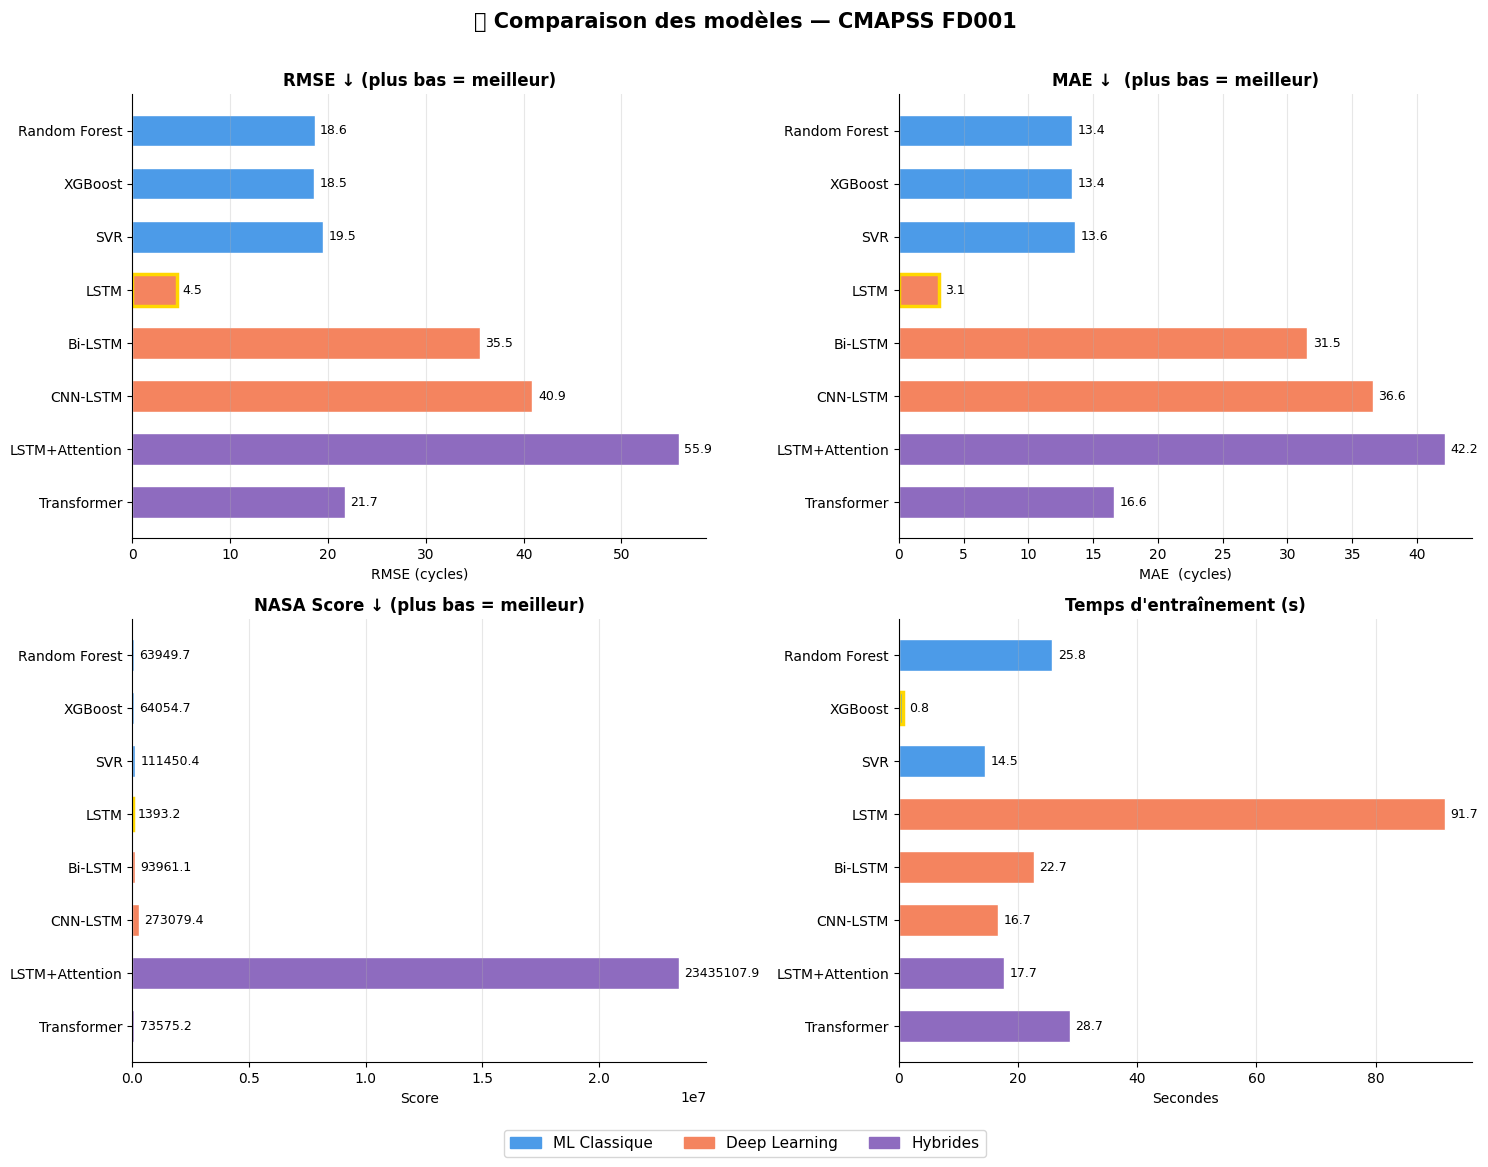

✅ Figure sauvegardée : model_comparison.png


In [ ]:
models_names = [r['Model'] for r in results]
rmse_vals    = [r['RMSE']  for r in results]
mae_vals     = [r['MAE']   for r in results]
nasa_vals    = [r['NASA_Score'] for r in results]
time_vals    = [r['Train_Time_s'] for r in results]

# Couleurs par catégorie
CAT_COLORS = {
    'Random Forest' : '#4C9BE8',
    'XGBoost'       : '#4C9BE8',
    'SVR'           : '#4C9BE8',
    'LSTM'          : '#F4845F',
    'Bi-LSTM'       : '#F4845F',
    'CNN-LSTM'      : '#F4845F',
    'LSTM+Attention': '#8E6BBF',
    'Transformer'   : '#8E6BBF',
}
colors = [CAT_COLORS.get(m, '#888') for m in models_names]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('🏆 Comparaison des modèles — CMAPSS FD001', fontsize=15, fontweight='bold', y=1.01)

def bar_chart(ax, vals, title, ylabel, color_list, best='min'):
    bars = ax.barh(models_names, vals, color=color_list, edgecolor='white', height=0.6)
    best_val = min(vals) if best == 'min' else max(vals)
    for bar, val in zip(bars, vals):
        ax.text(val + max(vals)*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', fontsize=9)
        if val == best_val:
            bar.set_edgecolor('gold'); bar.set_linewidth(2.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(ylabel)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

bar_chart(axes[0,0], rmse_vals,  'RMSE ↓ (plus bas = meilleur)',  'RMSE (cycles)', colors)
bar_chart(axes[0,1], mae_vals,   'MAE ↓  (plus bas = meilleur)',  'MAE  (cycles)', colors)
bar_chart(axes[1,0], nasa_vals,  'NASA Score ↓ (plus bas = meilleur)', 'Score', colors)
bar_chart(axes[1,1], time_vals,  "Temps d'entraînement (s)",      'Secondes', colors, best='min')

# Légende des catégories
legend_patches = [
    mpatches.Patch(color='#4C9BE8', label='ML Classique'),
    mpatches.Patch(color='#F4845F', label='Deep Learning'),
    mpatches.Patch(color='#8E6BBF', label='Hybrides'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           frameon=True, fontsize=11, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure sauvegardée : model_comparison.png')

## 🔍 16. RUL Prédit vs Réel — pour chaque modèle

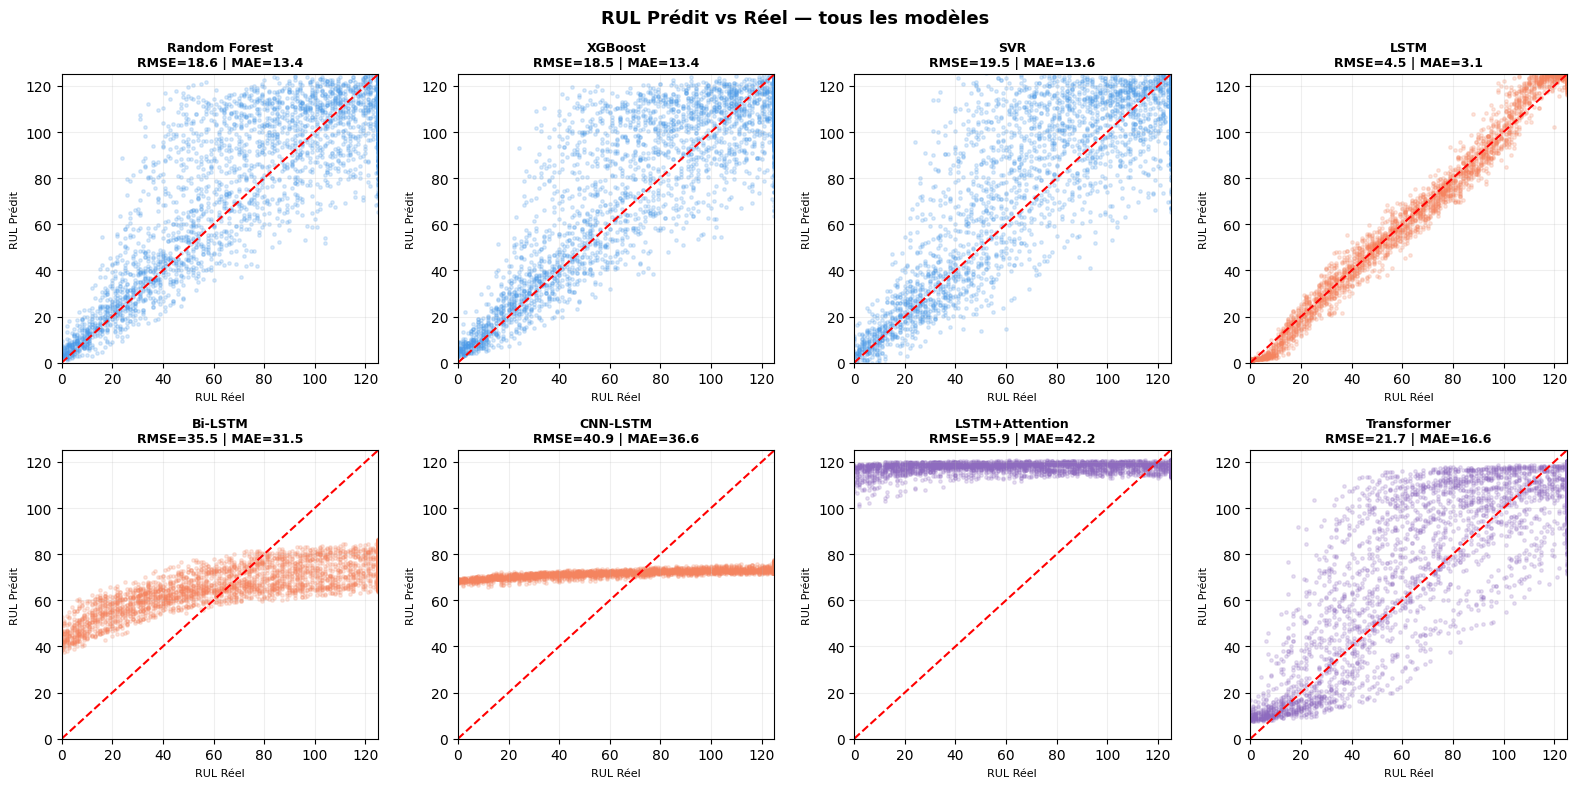

In [ ]:
n_models = len(results)
n_cols   = 4
n_rows   = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, r in enumerate(results):
    y_t = r['y_true']
    y_p = r['y_pred']
    ax  = axes[i]

    ax.scatter(y_t, y_p, alpha=0.2, s=6, color=list(CAT_COLORS.values())[i % len(CAT_COLORS)])
    lim = [0, RUL_MAX]
    ax.plot(lim, lim, 'r--', linewidth=1.5)
    ax.set_title(f"{r['Model']}\nRMSE={r['RMSE']:.1f} | MAE={r['MAE']:.1f}",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('RUL Réel', fontsize=8)
    ax.set_ylabel('RUL Prédit', fontsize=8)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.grid(alpha=0.2)

# Masquer les subplots vides
for j in range(n_models, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('RUL Prédit vs Réel — tous les modèles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🎖️ 17. Résumé final & Recommandation

In [ ]:
df_sorted = df_results.sort_values('RMSE ↓')
best_model = df_sorted.iloc[0]

print('=' * 55)
print('🎖️  RÉSUMÉ FINAL — CMAPSS FD001')
print('=' * 55)
print(f"\n🥇 Meilleur modèle  : {best_model['Modèle']}")
print(f"   RMSE             : {best_model['RMSE ↓']} cycles")
print(f"   MAE              : {best_model['MAE ↓']} cycles")
print(f"   NASA Score       : {best_model['NASA Score ↓']}")
print(f"   Temps train      : {best_model['Temps (s) ↓']} s")

print('\n📋 Classement complet :')
for i, row in df_sorted.iterrows():
    medal = '🥇' if i == df_sorted.index[0] else ('🥈' if i == df_sorted.index[1] else ('🥉' if i == df_sorted.index[2] else '  '))
    print(f"  {medal} {row['Modèle']:<20} RMSE={row['RMSE ↓']:.2f}  MAE={row['MAE ↓']:.2f}  NASA={row['NASA Score ↓']:.0f}")

print('\n💡 Conseil :')
print('   • ML Classique  → rapide, bon pour baseline')
print('   • LSTM / BiLSTM → bon équilibre perf/temps')
print('   • Transformer   → meilleur sur grands datasets')
print('   • LSTM+Attention→ excellent sur FD001 (1 condition)')
print('=' * 55)

# Sauvegarde CSV
df_results.to_csv('rul_comparison_results.csv', index=False)
print('\n✅ Résultats exportés : rul_comparison_results.csv')
files.download('rul_comparison_results.csv')
files.download('model_comparison.png')

🎖️  RÉSUMÉ FINAL — CMAPSS FD001

🥇 Meilleur modèle  : LSTM
   RMSE             : 4.52 cycles
   MAE              : 3.13 cycles
   NASA Score       : 1393.0
   Temps train      : 91.7 s

📋 Classement complet :
  🥇 LSTM                 RMSE=4.52  MAE=3.13  NASA=1393
  🥈 XGBoost              RMSE=18.55  MAE=13.37  NASA=64055
  🥉 Random Forest        RMSE=18.62  MAE=13.37  NASA=63950
     SVR                  RMSE=19.49  MAE=13.58  NASA=111450
     Transformer          RMSE=21.69  MAE=16.59  NASA=73575
     Bi-LSTM              RMSE=35.52  MAE=31.52  NASA=93961
     CNN-LSTM             RMSE=40.89  MAE=36.59  NASA=273079
     LSTM+Attention       RMSE=55.86  MAE=42.16  NASA=23435108

💡 Conseil :
   • ML Classique  → rapide, bon pour baseline
   • LSTM / BiLSTM → bon équilibre perf/temps
   • Transformer   → meilleur sur grands datasets
   • LSTM+Attention→ excellent sur FD001 (1 condition)

✅ Résultats exportés : rul_comparison_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>